# LOFO full analysis -- confusion matrices, curve/Ct similarity, attn-recon, saliency, learning curves

Six independent analyses of `final_6_new` LOFO results, all keyed off the
same `MODEL`/`GROUP_NAME`/`CURVE_TYPE`/`TRAIN_CENTER_FRAC` config below:

1. **Confusion matrices** -- 1 figure per model, 1 panel per held-out chip (reads cached
   predictions, no model loading -- covers every model, not just `MODEL`).
2. **Curve-shape distance matrix** -- held-out labels (rows) vs. training labels (cols),
   mean +/- std Euclidean distance between well-mean curves.
3. **Ct distance matrix** -- same layout as (2), but on the `Ct` kinetic feature already
   stored in `curve_for_training.joblib` (cheap to retrieve, no re-fitting).
4. **Attn-recon inspection** (`MODEL` only) -- per held-out chip, raw vs. attn-recon
   curves, one row per target label plus an "ALL" row.
5. **Saliency maps** (`MODEL` only) -- one held-out sample vs. one training sample per
   target label.
6. **Learning curves** -- per held-out chip, loss/accuracy over epochs for every model
   with cached training history.

All six loop over every chip in `GROUP_NAME`. (1) and (6) only need `load_lofo_results`
(cheap, no GPU). (2)/(3) rebuild one PC-TTP-aligned pool per held-out chip (moderate
cost). (4)/(5) additionally load each fold's saved `.keras` model and run it (the most
expensive pair) -- `compute_attn_recon` processes one well at a time rather than the
whole chip at once to keep peak memory bounded on this machine (shared box, swap often
exhausted).

In [11]:
import os, sys, importlib, math, colorsys, gc
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.spatial.distance import cdist, pdist
from sklearn.metrics import confusion_matrix

try:
    notebook_path = globals().get('__vsc_ipynb_file__')
    if notebook_path:
        os.chdir(os.path.dirname(os.path.dirname(notebook_path)))
except Exception as e:
    print(f"Could not change directory: {e}")

print("CWD:", os.getcwd())
%load_ext autoreload
%autoreload 2
import config

sys.path.insert(0, 'utils')
sys.path.insert(0, 'utils/model_training')
from model_utils import build_neighbor_curve_stack, _QuerySlice, _AttnScores, _WeightedRecon

# Import-only -- none of these .py files are modified.
cdt   = importlib.import_module("04_cross_dataset_training")
p08   = importlib.import_module("08_cross_dataset_predict_new_chip")
vis07 = importlib.import_module("07_attribution_vis_all")
rio   = importlib.import_module("cross_dataset_result_io")
b06   = importlib.import_module("06b_cross_dataset_prediction_report")

import tensorflow as tf
tf.config.optimizer.set_jit(False)

%matplotlib inline
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.linestyle': '--', 'grid.alpha': 0.3, 'font.size': 9})
print("Imports OK.")

CWD: /vol/bitbucket/gk225/POC_DDM/gk_code/main
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Imports OK.


## Configuration

In [12]:
MODEL             = "cnn_gru_dual_attn_recon"
GROUP_NAME        = "final_6_new"
TRAIN_CENTER_FRAC = 0.5
CURVE_TYPE        = "ori_curve_sg_p4_norm"
CURVE_ALIGNMENT   = "pc_ttp"
PC_TTP_ANCHOR     = "min"
EXP_FOLDER        = config.FINAL_EXP_FOLDER
OUTLIER_FILTER    = "noamp_remove"
MODE_STR          = "lofo"

FAMILY_LABELS = {
    'cnn_gru_dual_attn_recon':   'CNN-BiGRU + Spatial Attn',
    'cnn_gru_dual_attn_recon_aug': 'CNN-BiGRU + Spatial Attn\n+ Temporal Aug',
    'cnn_gru_dual_attn_recon_dann': 'CNN-BiGRU + Spatial Attn\n+ DANN',
    'cnn_gru_dual_attn_recon_supcon3': 'CNN-BiGRU + Spatial Attn\n+ Contrastive Loss',
    'cnn_gru_dual_attn_recon_pc_recenter': 'CNN-BiGRU + Spatial Attn\n+ Latent Alignment',
}

folder_names = config.CROSS_DATASET_GROUPS[GROUP_NAME]
exp_paths = [Path(EXP_FOLDER, name) for name in folder_names]

def short_name(folder):
    tail = folder.split('_U_', 1)[1]  # e.g. 'DDM_01_final_final' or 'DDM_05_01'
    parts = tail.split('_')
    return f"Chip {parts[1]}" if len(parts) > 1 and parts[0] == 'DDM' else tail

def group_dir(group_name):
    return Path(EXP_FOLDER) / "cross_dataset_cv" / group_name

def lofo_group_dir(group_name):
    return b06.alignment_dir(group_dir(group_name), CURVE_ALIGNMENT, PC_TTP_ANCHOR)

pc_ttp_cache_dir = lofo_group_dir(GROUP_NAME) / "_cache_pc_ttp"

def load_lofo_results(group_name, curve_type, train_center_frac=TRAIN_CENTER_FRAC):
    out_dir = lofo_group_dir(group_name)
    legacy_path = b06.find_results_path(out_dir, MODE_STR, curve_type)
    return b06.load_partitioned(out_dir, MODE_STR, curve_type, legacy_path=legacy_path,
                                train_center_frac=train_center_frac)

lofo_results = load_lofo_results(GROUP_NAME, CURVE_TYPE)
ALL_LOFO_FOLDS = sorted(k for k in lofo_results if k.startswith("lofo_"))
print(f"Group '{GROUP_NAME}' -> {len(folder_names)} chips, {len(ALL_LOFO_FOLDS)} LOFO fold(s) on disk:")
for n in folder_names:
    tag = "" if f"lofo_{n}" in ALL_LOFO_FOLDS else "  [NO CACHED RESULTS]"
    print(f"  - {n} ({short_name(n)}){tag}")

Group 'final_6_new' -> 6 chips, 0 LOFO fold(s) on disk:
  - D20260827_E00_C00_F4500KHz_U_DDM_01_final_final (DDM_01_final_final)  [NO CACHED RESULTS]
  - D20260827_E00_C00_F4500KHz_U_DDM_02_final_final (DDM_02_final_final)  [NO CACHED RESULTS]
  - D20260827_E00_C00_F4500KHz_U_DDM_03_final_final (DDM_03_final_final)  [NO CACHED RESULTS]
  - D20260827_E00_C00_F4500KHz_U_DDM_04_final_final (DDM_04_final_final)  [NO CACHED RESULTS]
  - D20260825_E00_C00_F4500KHz_U_DDM_05_01 (DDM_05_01)  [NO CACHED RESULTS]
  - D20260825_E00_C00_F4500KHz_U_DDM_06_02 (DDM_06_02)  [NO CACHED RESULTS]


## Data profile -- training vs. held-out, per target label

Confusion-matrix-style: for each held-out chip, 2 rows (Training = the other 5 chips
pooled, Held-out = that chip alone) x 1 column per target label, cell = sample count
+ % of that row's total. Counts come straight from `config.apply_well_exclusion`
(the same exclusion every LOFO pool applies -- PC/NC-ALL and any chip-specific extra
exclusions are already dropped), no curve loading/resampling needed so this covers
every chip in the group.

  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1686 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260827_E00_C00_F4500KHz_U_DDM_01_final_final
  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1828 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260827_E00_C00_F4500KHz_U_DDM_02_final_final
  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1842 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260827_E00_C00_F4500KHz_U_DDM_03_final_final
  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1774 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260827_E00_C00_F4500KHz_U_DDM_04_final_final
  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1901 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8:

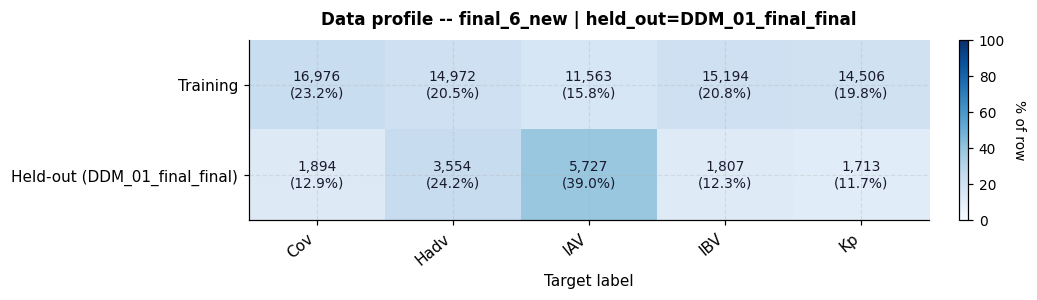

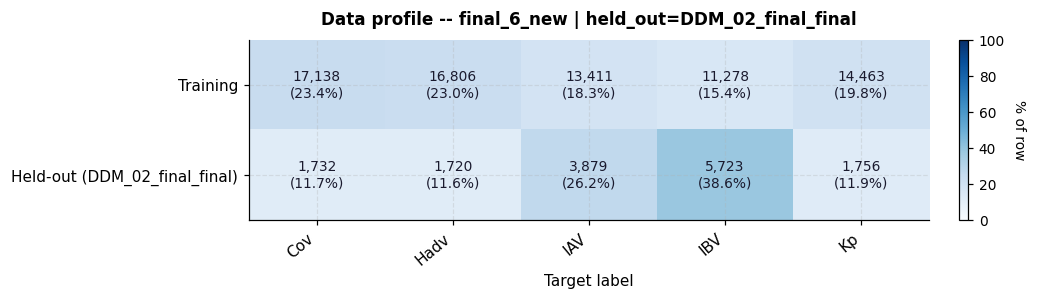

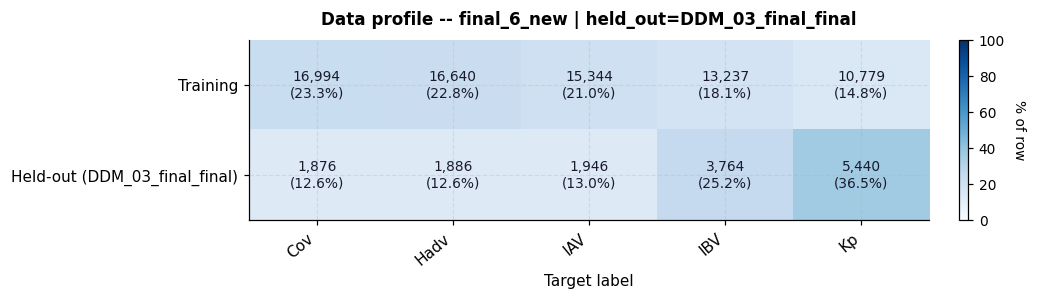

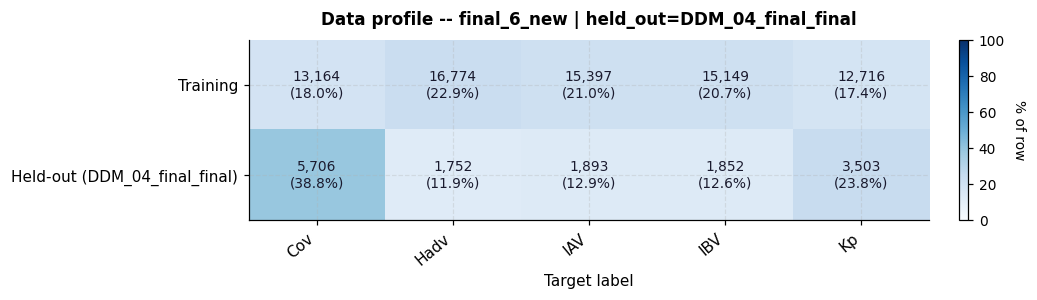

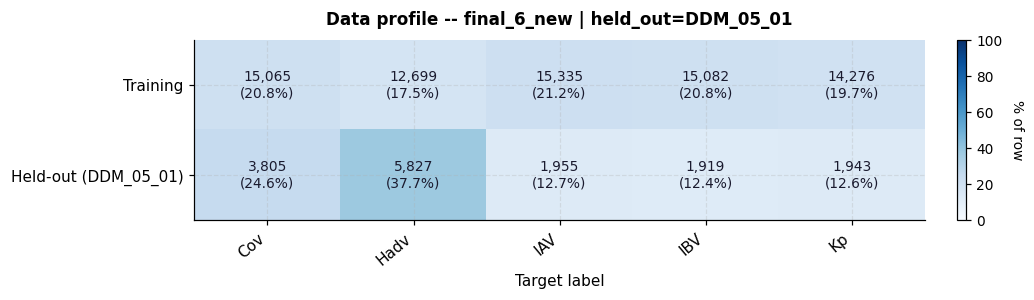

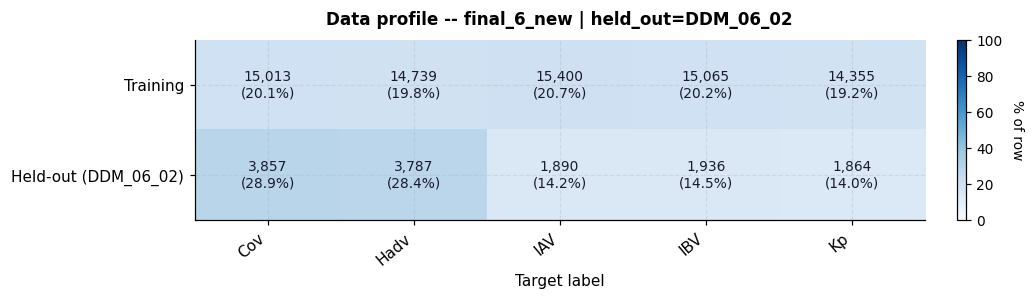

In [13]:
def load_label_counts(exp_paths, group_name):
    records = []
    for exp_path in exp_paths:
        data_path = os.path.join(exp_path, config.TRAINING_DATA_PATH)
        if not os.path.exists(data_path):
            continue
        data = joblib.load(data_path)
        data = config.apply_well_exclusion(data, exp_path.name, group_name=group_name)
        label_mappings = config.get_label_mappings(exp_path)
        if exp_path.name not in label_mappings:
            continue
        mapping = label_mappings[exp_path.name]
        Y_mapped = np.array([mapping.get(w, w) for w in np.asarray(data["Y_well"])])
        for label, count in zip(*np.unique(Y_mapped, return_counts=True)):
            records.append({"dataset_id": exp_path.name, "label": label, "count": int(count)})
    return pd.DataFrame.from_records(records)


def plot_data_profile(label_counts_df, held_out_chip, exclude_labels=("PC", "NC-ALL"), figsize_per_col=1.5):
    df = label_counts_df[~label_counts_df["label"].isin(exclude_labels)]
    is_ho = df["dataset_id"] == held_out_chip
    training = df[~is_ho].groupby("label")["count"].sum()
    held_out = df[is_ho].groupby("label")["count"].sum()
    labels = sorted(set(training.index) | set(held_out.index))
    row_labels = ["Training", f"Held-out ({short_name(held_out_chip)})"]

    mat = np.zeros((2, len(labels)))
    for j, lbl in enumerate(labels):
        mat[0, j] = training.get(lbl, 0)
        mat[1, j] = held_out.get(lbl, 0)
    row_totals = mat.sum(axis=1, keepdims=True)
    pct = np.divide(mat, row_totals, out=np.zeros_like(mat), where=row_totals != 0) * 100

    fig, ax = plt.subplots(figsize=(figsize_per_col * len(labels) + 2, 2.8), facecolor='white')
    im = ax.imshow(pct, cmap='Blues', vmin=0, vmax=100, aspect='auto')
    for i in range(2):
        for j in range(len(labels)):
            ax.text(j, i, f"{int(mat[i, j]):,}\n({pct[i, j]:.1f}%)", ha='center', va='center', fontsize=9,
                    color='white' if pct[i, j] > 50 else '#1a1a2e')
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=10)
    ax.set_yticks(range(2)); ax.set_yticklabels(row_labels, fontsize=10)
    ax.set_xlabel('Target label', fontsize=10)
    ax.set_title(f'Data profile -- {GROUP_NAME} | held_out={short_name(held_out_chip)}',
                fontsize=11, fontweight='bold', pad=10)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label('% of row', rotation=270, labelpad=14, fontsize=9)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


label_counts_df = load_label_counts(exp_paths, GROUP_NAME)
for chip_name in folder_names:
    plot_data_profile(label_counts_df, chip_name)

## 1. Confusion matrices -- 1 figure per model, 1 panel per held-out chip

Computed directly from cached raw predictions (`y_trues_`/`y_preds_AC_{model}_`),
row-normalized. Covers every model with cached predictions for every fold found in
`lofo_results` (not restricted to `MODEL` -- this is read-only,
no model loading, so there's no reason to restrict it).

In [14]:
def plot_lofo_confusion_matrices(lofo_results, model, filter_name=OUTLIER_FILTER,
                                 normalize=True, figsize_per_cell=(3.2, 3.6)):
    preds_key = config.MODEL_KEY_MAP.get(model, (None,))[0]
    if preds_key is None:
        print(f"[!] Unknown model key: {model!r}")
        return

    fold_labels = sorted(k for k in lofo_results if k.startswith("lofo_"))
    panels = []
    for fold_label in fold_labels:
        fold_entry = lofo_results[fold_label]
        res_entry = fold_entry.get(filter_name)
        class_names = fold_entry.get("class_names")
        if res_entry is None or class_names is None or preds_key not in res_entry:
            continue
        y_true = np.concatenate(res_entry["y_trues_"])
        y_pred = np.concatenate(res_entry[preds_key])
        cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))
        with np.errstate(invalid='ignore', divide='ignore'):
            cm_disp = cm / cm.sum(axis=1, keepdims=True) if normalize else cm
        panels.append((fold_label.replace("lofo_", ""), class_names, cm, cm_disp))

    if not panels:
        print(f"[!] No LOFO results for model {model!r} ({GROUP_NAME}/{CURVE_TYPE}/{filter_name}).")
        return

    n = len(panels)
    fig, axes = plt.subplots(1, n, figsize=(figsize_per_cell[0] * n, figsize_per_cell[1]), squeeze=False)
    axes = axes[0]
    for ax, (held_out, class_names, cm, cm_disp) in zip(axes, panels):
        ax.imshow(cm_disp, cmap='Blues', vmin=0, vmax=1 if normalize else None)
        ax.set_xticks(range(len(class_names))); ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=8)
        ax.set_yticks(range(len(class_names))); ax.set_yticklabels(class_names, fontsize=8)
        for i in range(len(class_names)):
            for j in range(len(class_names)):
                val = cm_disp[i, j]
                text = f"{val:.2f}" if normalize else f"{cm[i, j]:,}"
                color = 'white' if (not np.isnan(val) and val > 0.5) else 'black'
                ax.text(j, i, text, ha='center', va='center', fontsize=7, color=color)
        ax.set_title(short_name(held_out), fontsize=10, fontweight='bold')
        ax.set_xlabel('Predicted', fontsize=8)
    axes[0].set_ylabel('True', fontsize=8)
    fig.suptitle(f"LOFO confusion matrices -- {FAMILY_LABELS.get(model, model).replace(chr(10), ' ')}  |  "
                f"{GROUP_NAME} | {CURVE_TYPE}", fontsize=12, fontweight='bold', y=1.06)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


plot_lofo_confusion_matrices(lofo_results, MODEL)

[!] No LOFO results for model 'cnn_gru_dual_attn_recon' (final_6_new/ori_curve_sg_p4_norm/noamp_remove).


## Pool builder (shared by sections 2-5)

`build_pool` is the exact same PC-TTP-aligned pool `04_cross_dataset_training.py`
trains on for a given LOFO fold (all chips, incl. the held-out one -- `held_out_chip`
only picks the anchor/common_duration from the *other* chips).

In [15]:
def build_well_table(combined):
    df = pd.DataFrame({
        "well_id": combined["well_ids"],
        "dataset_id": combined["dataset_id"],
        "label": combined["Y_mapped"],
    })
    df["row_idx"] = np.arange(len(df))
    meta = df.groupby("well_id").agg(dataset_id=("dataset_id", "first"), label=("label", "first"))
    row_idx_map = df.groupby("well_id")["row_idx"].apply(np.array)
    wells = meta.join(row_idx_map.rename("row_idx")).reset_index()
    wells["n_pixels"] = wells["row_idx"].apply(len)
    return wells


def build_pool(held_out_chip, curve_type=CURVE_TYPE):
    return cdt.combine_group_pc_aligned(
        exp_paths, GROUP_NAME, curve_type, held_out_chip=held_out_chip,
        anchor_method=PC_TTP_ANCHOR, anchor_pct=cdt.PC_TTP_ANCHOR_PCT_DEFAULT,
        pc_ttp_cache_dir=pc_ttp_cache_dir)

## 2. Curve-shape distance matrix -- held-out labels vs. training labels

y-axis = held-out chip's target labels, x-axis = training chips' target labels, cell =
mean +/- std Euclidean distance between well-mean curves (PC/NC-ALL excluded -- reference
wells, not classification targets). Held-out and training wells are always disjoint sets
(LOFO), so every cell is a genuine cross-set comparison. Distance computation adapted
from `compute_label_pair_distance_matrix` in `0_LOFO_INSPECTION copy.ipynb`; layout
(1 figure, 1 panel per held-out chip) matches `plot_lofo_confusion_matrices` instead of
that notebook's original 1-figure-per-chip version.

  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1686 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260827_E00_C00_F4500KHz_U_DDM_01_final_final
  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1828 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260827_E00_C00_F4500KHz_U_DDM_02_final_final
  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1842 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260827_E00_C00_F4500KHz_U_DDM_03_final_final
  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1774 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260827_E00_C00_F4500KHz_U_DDM_04_final_final
  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1901 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8:

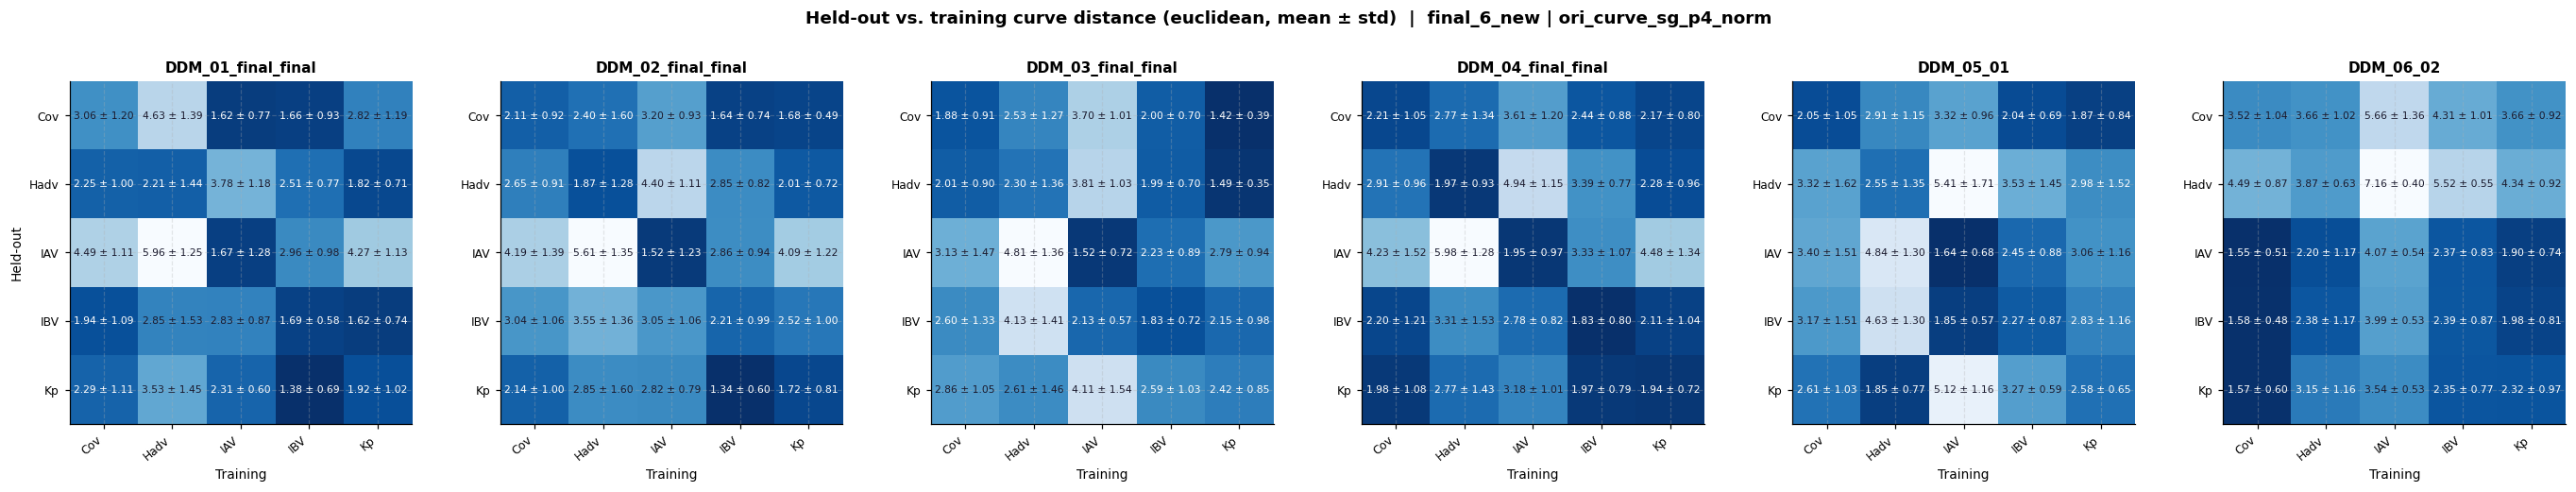

In [16]:
def compute_label_pair_distance_matrix(combined, held_out_chip, metric='euclidean'):
    wells = build_well_table(combined)
    wells = wells[~wells["label"].isin(["PC", "NC-ALL"])].reset_index(drop=True)
    well_curves = np.stack([combined["curves"][idx].mean(axis=0) for idx in wells["row_idx"]])
    well_labels = wells["label"].to_numpy()
    is_held_out = wells["dataset_id"].to_numpy() == held_out_chip

    test_curves, test_labels = well_curves[is_held_out], well_labels[is_held_out]
    train_curves, train_labels = well_curves[~is_held_out], well_labels[~is_held_out]

    row_labels = sorted(set(test_labels))
    col_labels = sorted(set(train_labels))
    mean_mat = np.full((len(row_labels), len(col_labels)), np.nan)
    std_mat  = np.full((len(row_labels), len(col_labels)), np.nan)
    n_mat    = np.zeros((len(row_labels), len(col_labels)), dtype=int)

    for i, li in enumerate(row_labels):
        Xi = test_curves[test_labels == li]
        for j, lj in enumerate(col_labels):
            Xj = train_curves[train_labels == lj]
            if len(Xi) == 0 or len(Xj) == 0:
                continue
            vals = cdist(Xi, Xj, metric=metric).ravel()
            mean_mat[i, j] = vals.mean()
            std_mat[i, j]  = vals.std()
            n_mat[i, j]    = len(vals)

    return row_labels, col_labels, mean_mat, std_mat, n_mat


def plot_label_distance_matrices(panels, title_prefix, figsize_per_cell=(4.2, 4.2)):
    """panels: list of (held_out_chip, row_labels, col_labels, mean_mat, std_mat, n_mat).
    1 figure, 1 panel per held-out chip -- mirrors plot_lofo_confusion_matrices' layout."""
    if not panels:
        print(f"[!] No panels to plot for {title_prefix!r}.")
        return
    n = len(panels)
    fig, axes = plt.subplots(1, n, figsize=(figsize_per_cell[0] * n, figsize_per_cell[1]), squeeze=False)
    axes = axes[0]
    for ax, (held_out, row_labels, col_labels, mean_mat, std_mat, n_mat) in zip(axes, panels):
        n_rows, n_cols = len(row_labels), len(col_labels)
        ax.imshow(mean_mat, cmap='Blues_r')
        overall_mean = np.nanmean(mean_mat)
        for i in range(n_rows):
            for j in range(n_cols):
                if np.isnan(mean_mat[i, j]):
                    ax.text(j, i, '—', ha='center', va='center', fontsize=8, color='#999')
                    continue
                ax.text(j, i, f'{mean_mat[i, j]:.2f} ± {std_mat[i, j]:.2f}',
                        ha='center', va='center', fontsize=7,
                        color='white' if mean_mat[i, j] < overall_mean else '#1a1a2e')
        ax.set_xticks(range(n_cols)); ax.set_xticklabels(col_labels, rotation=40, ha='right', fontsize=8)
        ax.set_yticks(range(n_rows)); ax.set_yticklabels(row_labels, fontsize=8)
        ax.set_xlabel('Training', fontsize=9)
        ax.set_title(short_name(held_out), fontsize=10, fontweight='bold')
    axes[0].set_ylabel('Held-out', fontsize=9)
    fig.suptitle(f"{title_prefix}  |  {GROUP_NAME} | {CURVE_TYPE}", fontsize=12, fontweight='bold', y=1.06)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


_curve_dist_panels = []
for held_out in folder_names:
    combined = build_pool(held_out)
    row_labels, col_labels, mean_mat, std_mat, n_mat = compute_label_pair_distance_matrix(combined, held_out)
    _curve_dist_panels.append((held_out, row_labels, col_labels, mean_mat, std_mat, n_mat))
    del combined
    gc.collect()
plot_label_distance_matrices(_curve_dist_panels, "Held-out vs. training curve distance (euclidean, mean ± std)")

### Overall curve-distance profile -- every chip x every target, all pairs

Not held-out-specific: every `(chip, target)` group compared against every other
`(chip, target)` group (including itself), so a 6-chip x 5-target group gives a 30x30
matrix. Same well-mean-curve + Euclidean-distance mechanism as the panels above, except
a group compared against itself uses `pdist` (excludes the trivial 0 self-distance a
`cdist` diagonal would otherwise pull the mean toward) instead of `cdist`. Dense enough
that per-cell mean +/- std text isn't legible, so this is a pure heatmap (colour only,
no text) with black divider lines separating chip blocks -- read it for the overall
pattern (which chips/targets run close together vs. far apart), not exact values.

  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1686 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260827_E00_C00_F4500KHz_U_DDM_01_final_final
  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1828 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260827_E00_C00_F4500KHz_U_DDM_02_final_final
  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1842 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260827_E00_C00_F4500KHz_U_DDM_03_final_final
  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1774 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260827_E00_C00_F4500KHz_U_DDM_04_final_final
  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1901 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8:

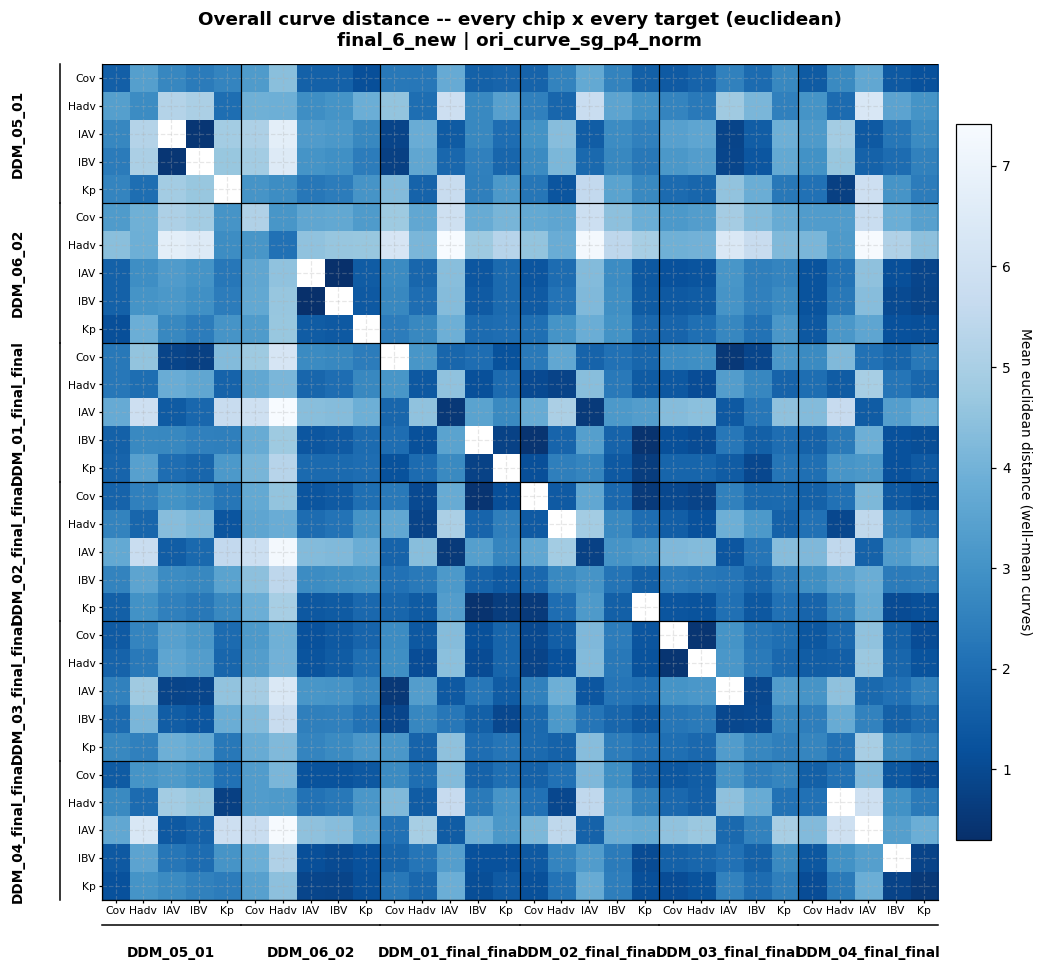

14118

In [17]:
def compute_chip_target_distance_matrix(combined_all, metric='euclidean', exclude_labels=("PC", "NC-ALL")):
    wells = build_well_table(combined_all)
    wells = wells[~wells["label"].isin(exclude_labels)].reset_index(drop=True)
    well_curves = np.stack([combined_all["curves"][idx].mean(axis=0) for idx in wells["row_idx"]])
    groups_per_well = list(zip(wells["dataset_id"], wells["label"]))
    unique_groups = sorted(set(groups_per_well), key=lambda g: (g[0], g[1]))
    group_idx = {g: np.array([i for i, gg in enumerate(groups_per_well) if gg == g]) for g in unique_groups}

    n = len(unique_groups)
    mean_mat = np.full((n, n), np.nan)
    for i, gi in enumerate(unique_groups):
        Xi = well_curves[group_idx[gi]]
        for j, gj in enumerate(unique_groups):
            Xj = well_curves[group_idx[gj]]
            if len(Xi) == 0 or len(Xj) == 0:
                continue
            if gi == gj:
                if len(Xi) < 2:
                    continue
                vals = pdist(Xi, metric=metric)
            else:
                vals = cdist(Xi, Xj, metric=metric).ravel()
            if len(vals):
                mean_mat[i, j] = vals.mean()
    return unique_groups, mean_mat


def plot_chip_target_distance_matrix(groups, mean_mat, title, cbar_label, figsize=(11, 10)):
    """2-level axis labels: the primary ticks are just the target name, and one bold
    chip label spans each chip's block of consecutive ticks (below the x-axis, left of
    the y-axis) -- instead of repeating "chip\\ntarget" on every single tick."""
    n = len(groups)
    fig, ax = plt.subplots(figsize=figsize, facecolor='white')
    im = ax.imshow(mean_mat, cmap='Blues_r')
    fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02).set_label(cbar_label, rotation=270, labelpad=14, fontsize=9)

    target_labels = [label for _, label in groups]
    ax.set_xticks(range(n)); ax.set_xticklabels(target_labels, fontsize=7)
    ax.set_yticks(range(n)); ax.set_yticklabels(target_labels, fontsize=7)
    ax.tick_params(axis='both', length=2, pad=2)

    boundaries, chip_spans, prev_chip, start = [], [], None, 0
    for i, (chip, _) in enumerate(groups):
        if chip != prev_chip:
            if prev_chip is not None:
                chip_spans.append((prev_chip, start, i - 1))
            boundaries.append(i - 0.5)
            prev_chip, start = chip, i
    chip_spans.append((prev_chip, start, n - 1))
    boundaries.append(n - 0.5)

    for b in boundaries:
        ax.axhline(b, color='black', lw=0.8)
        ax.axvline(b, color='black', lw=0.8)

    for chip, lo, hi in chip_spans:
        mid = (lo + hi) / 2
        # x-axis transform: x in data coords, y in axes-fraction (0=axis line, <0 below it).
        ax.text(mid, -0.055, short_name(chip), transform=ax.get_xaxis_transform(),
               ha='center', va='top', fontsize=9, fontweight='bold')
        ax.plot([lo - 0.5, hi + 0.5], [-0.03, -0.03], transform=ax.get_xaxis_transform(),
               color='black', lw=1.0, clip_on=False)
        # y-axis transform: x in axes-fraction (0=axis line, <0 left of it), y in data coords.
        ax.text(-0.10, mid, short_name(chip), transform=ax.get_yaxis_transform(),
               ha='center', va='center', fontsize=9, fontweight='bold', rotation=90)
        ax.plot([-0.05, -0.05], [lo - 0.5, hi + 0.5], transform=ax.get_yaxis_transform(),
               color='black', lw=1.0, clip_on=False)

    ax.set_title(f"{title}\n{GROUP_NAME} | {CURVE_TYPE}", fontsize=12, fontweight='bold', pad=12)
    fig.subplots_adjust(left=0.16, bottom=0.14, right=0.90, top=0.90)
    plt.show()
    plt.close(fig)


# build_pool's held_out_chip argument only picks which OTHER chips set the PC-TTP anchor/
# common_duration -- the returned pool always covers every chip in the group, so any chip
# works here as an arbitrary anchor donor; it doesn't affect what's being measured.
combined_all = build_pool(folder_names[0])
_curve_groups, _curve_mean_mat = compute_chip_target_distance_matrix(combined_all)
plot_chip_target_distance_matrix(_curve_groups, _curve_mean_mat,
                                 "Overall curve distance -- every chip x every target (euclidean)",
                                 "Mean euclidean distance (well-mean curves)")
del combined_all
gc.collect()

## 3. Ct distance matrix -- held-out labels vs. training labels

Same layout as (2), but on the `Ct` kinetic feature (time-to-threshold) already stored
in `curve_for_training.joblib`'s `kinetic_features` -- confirmed present, non-NaN, and
row-aligned with `dataset`/`Y_well` after `config.apply_well_exclusion` (which filters
`kinetic_features` with the identical `keep_idx` as `dataset`/`Y_well`/`metadata`). Read
directly, no re-fitting -- if `Ct` were missing this section would be skipped (it isn't).

  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1686 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260827_E00_C00_F4500KHz_U_DDM_01_final_final
  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1828 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260827_E00_C00_F4500KHz_U_DDM_02_final_final
  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1842 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260827_E00_C00_F4500KHz_U_DDM_03_final_final
  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1774 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260827_E00_C00_F4500KHz_U_DDM_04_final_final
  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1901 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8:

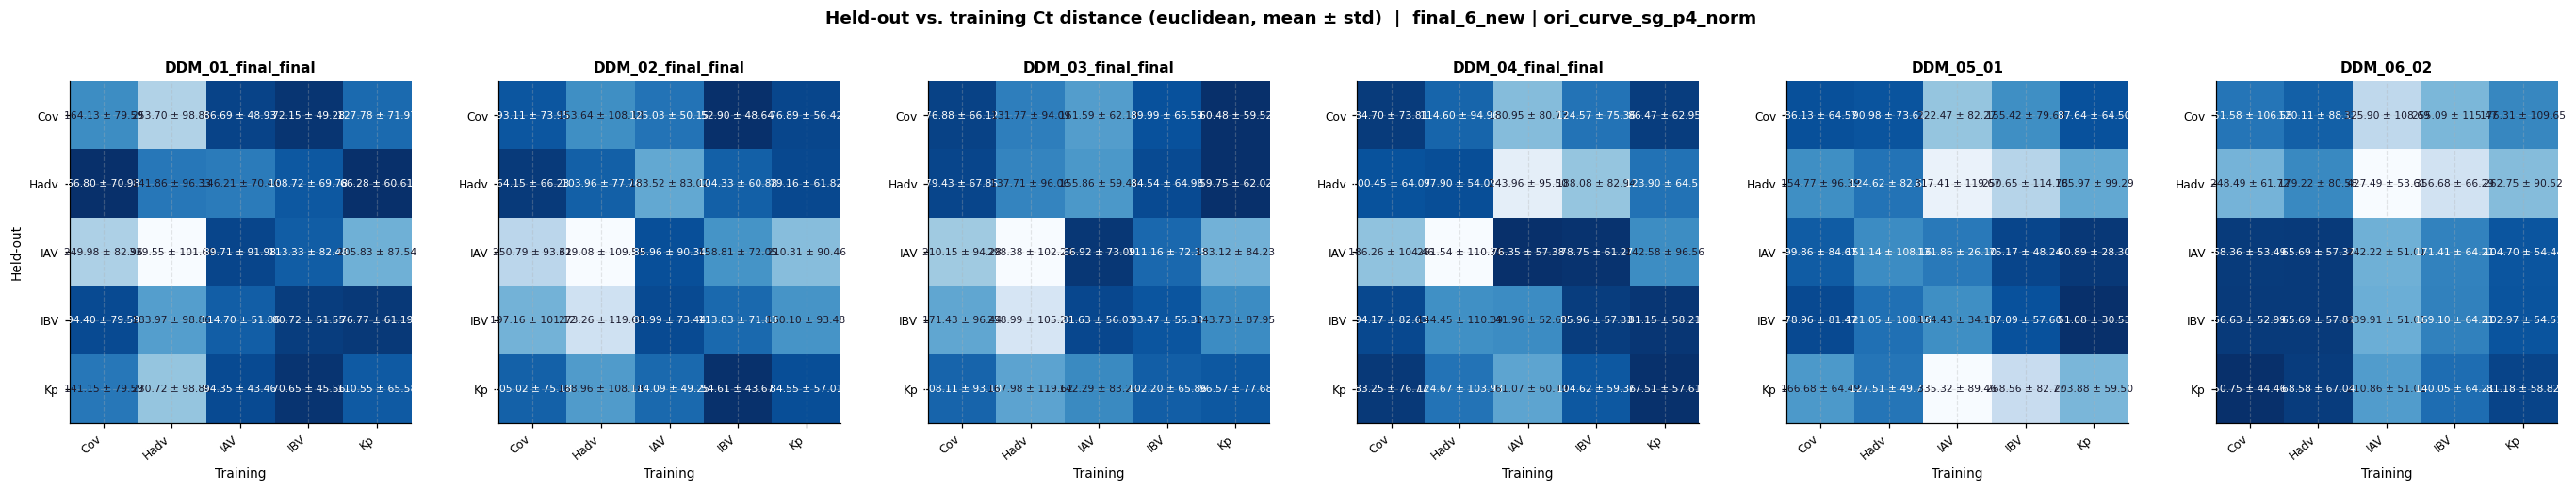

In [18]:
def load_ct_pool(exp_paths, curve_type, group_name):
    """Per-well-pixel Ct + dataset_id + well_ids + Y_mapped, built the same way
    load_curve_data does (apply_well_exclusion first) but pulling the 'Ct' column out
    of kinetic_features instead of the curve array. No resampling needed -- Ct is a
    scalar per pixel, not a time series."""
    ct_parts, dataset_id_parts, well_id_parts, label_parts = [], [], [], []
    for exp_path in exp_paths:
        data_path = os.path.join(exp_path, config.TRAINING_DATA_PATH)
        if not os.path.exists(data_path):
            continue
        data = joblib.load(data_path)
        data = config.apply_well_exclusion(data, exp_path.name, group_name=group_name)
        dataset_name = list(data["dataset_name"])
        try:
            idx, _ = config.resolve_curve_dataset_idx(curve_type, dataset_name)
        except ValueError:
            continue
        if "Ct" not in data["kinetic_features"][idx].columns:
            print(f"  [!] {exp_path.name}: no 'Ct' column in kinetic_features -- skipping.")
            continue
        label_mappings = config.get_label_mappings(exp_path)
        if exp_path.name not in label_mappings:
            continue
        mapping = label_mappings[exp_path.name]
        Y_well_raw = np.asarray(data["Y_well"])
        Y_mapped = np.array([mapping.get(w, w) for w in Y_well_raw])
        ct = data["kinetic_features"][idx]["Ct"].to_numpy()
        n = len(ct)
        ct_parts.append(ct)
        dataset_id_parts.append(np.full(n, exp_path.name, dtype=object))
        well_id_parts.append(np.array([f"{exp_path.name}::{w}" for w in Y_well_raw], dtype=object))
        label_parts.append(Y_mapped)
    if not ct_parts:
        return None
    return {
        "Ct": np.concatenate(ct_parts, axis=0),
        "dataset_id": np.concatenate(dataset_id_parts, axis=0),
        "well_ids": np.concatenate(well_id_parts, axis=0),
        "Y_mapped": np.concatenate(label_parts, axis=0),
    }


def compute_label_pair_ct_matrix(ct_pool, held_out_chip):
    df = pd.DataFrame({"well_id": ct_pool["well_ids"], "dataset_id": ct_pool["dataset_id"],
                       "label": ct_pool["Y_mapped"], "Ct": ct_pool["Ct"]})
    df = df[~df["label"].isin(["PC", "NC-ALL"])]
    well_ct = df.groupby("well_id").agg(dataset_id=("dataset_id", "first"), label=("label", "first"),
                                        Ct=("Ct", "mean")).reset_index()

    is_held_out = well_ct["dataset_id"].to_numpy() == held_out_chip
    test_ct, test_labels = well_ct["Ct"].to_numpy()[is_held_out], well_ct["label"].to_numpy()[is_held_out]
    train_ct, train_labels = well_ct["Ct"].to_numpy()[~is_held_out], well_ct["label"].to_numpy()[~is_held_out]

    row_labels = sorted(set(test_labels))
    col_labels = sorted(set(train_labels))
    mean_mat = np.full((len(row_labels), len(col_labels)), np.nan)
    std_mat  = np.full((len(row_labels), len(col_labels)), np.nan)
    n_mat    = np.zeros((len(row_labels), len(col_labels)), dtype=int)

    for i, li in enumerate(row_labels):
        Xi = test_ct[test_labels == li].reshape(-1, 1)
        for j, lj in enumerate(col_labels):
            Xj = train_ct[train_labels == lj].reshape(-1, 1)
            if len(Xi) == 0 or len(Xj) == 0:
                continue
            vals = cdist(Xi, Xj, metric='euclidean').ravel()
            mean_mat[i, j] = vals.mean()
            std_mat[i, j]  = vals.std()
            n_mat[i, j]    = len(vals)

    return row_labels, col_labels, mean_mat, std_mat, n_mat


ct_pool = load_ct_pool(exp_paths, CURVE_TYPE, GROUP_NAME)
if ct_pool is None:
    print("[!] Ct not retrievable from the saved joblib for this group/curve_type -- skipping section 3.")
else:
    _ct_dist_panels = []
    for held_out in folder_names:
        row_labels, col_labels, mean_mat, std_mat, n_mat = compute_label_pair_ct_matrix(ct_pool, held_out)
        _ct_dist_panels.append((held_out, row_labels, col_labels, mean_mat, std_mat, n_mat))
    plot_label_distance_matrices(_ct_dist_panels, "Held-out vs. training Ct distance (euclidean, mean ± std)")

### Overall Ct-distance profile -- every chip x every target, all pairs

Same idea as the curve-distance profile above, on `Ct` instead of the full curve
shape -- every `(chip, target)` group vs. every other group (including itself via
`pdist`, to avoid a trivial 0 self-distance pulling a diagonal cell's mean down).

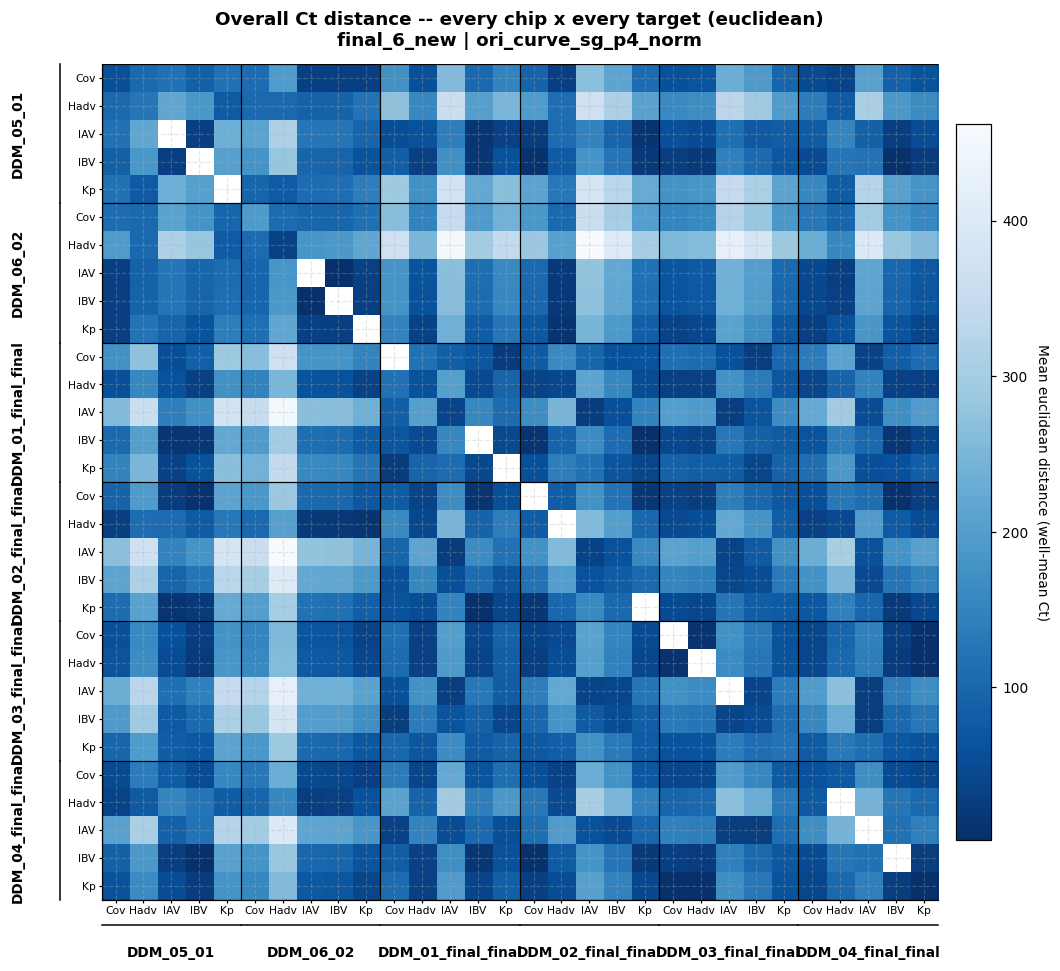

In [19]:
def compute_chip_target_ct_distance_matrix(ct_pool, metric='euclidean', exclude_labels=("PC", "NC-ALL")):
    df = pd.DataFrame({"well_id": ct_pool["well_ids"], "dataset_id": ct_pool["dataset_id"],
                       "label": ct_pool["Y_mapped"], "Ct": ct_pool["Ct"]})
    df = df[~df["label"].isin(exclude_labels)]
    well_ct = df.groupby("well_id").agg(dataset_id=("dataset_id", "first"), label=("label", "first"),
                                        Ct=("Ct", "mean")).reset_index()

    groups_per_well = list(zip(well_ct["dataset_id"], well_ct["label"]))
    unique_groups = sorted(set(groups_per_well), key=lambda g: (g[0], g[1]))
    group_idx = {g: np.array([i for i, gg in enumerate(groups_per_well) if gg == g]) for g in unique_groups}
    ct_vals = well_ct["Ct"].to_numpy()

    n = len(unique_groups)
    mean_mat = np.full((n, n), np.nan)
    for i, gi in enumerate(unique_groups):
        Xi = ct_vals[group_idx[gi]].reshape(-1, 1)
        for j, gj in enumerate(unique_groups):
            Xj = ct_vals[group_idx[gj]].reshape(-1, 1)
            if len(Xi) == 0 or len(Xj) == 0:
                continue
            if gi == gj:
                if len(Xi) < 2:
                    continue
                vals = pdist(Xi, metric=metric)
            else:
                vals = cdist(Xi, Xj, metric=metric).ravel()
            if len(vals):
                mean_mat[i, j] = vals.mean()
    return unique_groups, mean_mat


if ct_pool is None:
    print("[!] Ct not retrievable from the saved joblib for this group/curve_type -- skipping overall Ct profile.")
else:
    _ct_groups, _ct_mean_mat = compute_chip_target_ct_distance_matrix(ct_pool)
    plot_chip_target_distance_matrix(_ct_groups, _ct_mean_mat,
                                     "Overall Ct distance -- every chip x every target (euclidean)",
                                     "Mean euclidean distance (well-mean Ct)")

## Per-fold model loader (shared by sections 4-5)

Loads the actual LOFO-trained `.keras` model for `MODEL` on one held-out fold (the same
`model_interpretation/lofo_<chip>/` convention `lofo_pc_recenter_accuracy` uses in
`0_final_result_comparison_nnc.ipynb`), via `vis07.load_saved_models` (handles the
custom-object registration for every model family, not just the plain attn-recon
architecture `MODEL` defaults to). Reuses `build_pool`'s pool so the held-out and
training curves are guaranteed to sit on the exact grid the model expects (same
deterministic PC-TTP construction the training run itself used).

Each of sections 4/5 calls `prepare_fold` independently and frees the pool/model when
done (`free_fold`) rather than caching across sections -- this machine is memory-tight
(shared box, swap often exhausted), and a stray un-freed ~80k-row pool or loaded
`.keras` model from an earlier section is enough to push a later section's own
allocations (e.g. the neighbor-curve-stack, which is itself close to 1GB for one
chip) into a silent OOM kill with no Python traceback.

In [10]:
def load_fold_model(chip_name, expected_seq_len, model_key=MODEL,
                    train_center_frac=TRAIN_CENTER_FRAC, filter_name=OUTLIER_FILTER):
    model_dir = lofo_group_dir(GROUP_NAME) / "model_interpretation" / f"lofo_{chip_name}"
    loaded = vis07.load_saved_models(model_dir, filter_name, expected_seq_len, curve_type=CURVE_TYPE,
                                     model_names=[model_key], train_center_frac=train_center_frac)
    return loaded.get(model_key)


def prepare_fold(chip_name, model_key=MODEL):
    """Returns (combined, model, t_grid) for one held-out chip, or None if the pool or
    model isn't available. combined['dataset_id'] == chip_name selects held-out rows."""
    combined = build_pool(chip_name)
    if combined is None:
        print(f"[!] {chip_name}: could not build pool.")
        return None
    t_grid = np.asarray(combined["resampler"].t_grid, dtype=float)
    model = load_fold_model(chip_name, len(t_grid), model_key=model_key)
    if model is None:
        print(f"[!] {chip_name}: no saved '{model_key}' model for this fold "
              f"(expected seq_len={len(t_grid)}).")
        return None
    return combined, model, t_grid


def free_fold(prepared):
    """Explicitly drop a prepare_fold() result's large arrays/model + clear the Keras
    session -- see the memory note above."""
    if prepared is None:
        return
    combined, model, t_grid = prepared
    del combined, model
    tf.keras.backend.clear_session()
    gc.collect()

## 4. Attn-recon inspection (`MODEL` only) -- raw vs. attn-recon, per held-out chip

1 figure per held-out chip, 2 columns (left=raw, right=attn-recon), `n_labels + 1` rows
(1 row per target label present in that held-out chip, plus a final "ALL" row combining
every label) -- only the held-out chip's own curves are shown (the model was never
trained on them for classification, but the attn-recon spatial-pooling layer can still be
applied to any correctly-shaped neighbor stack). Adapted from `plot_raw_vs_attn`/
`plot_all_curves_by_label` in `4_visualise_recon_layer.ipynb`, split into one row per
label instead of one combined row.

In [ ]:
_CATEGORICAL_PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
                        "#e87ba4", "#008300", "#4a3aa7", "#e34948"]


def compute_attn_recon(combined, model, mask=None):
    """Attn-recon output for combined['curves'][mask] (default: every row), processed one
    WELL at a time. Two memory lessons learned the hard way on this machine (shared box,
    swap usually exhausted, sometimes only ~500MB truly free):
    (1) building the neighbor stack for the full 6-chip pool (~80k rows) allocates a
        (~80k, k+1, T) float array that exhausts host RAM and silently kills the process
        (no Python traceback) -- restricting to one chip's rows via `mask` fixed that.
    (2) even one held-out chip's *own* full row set (~13k rows) makes a ~1GB stack that
        can still tip this machine into the same silent death depending on what else is
        resident at the time (e.g. right after loading the .keras model). The k-NN
        neighbor search is per-well anyway (a pixel's neighbours only ever come from its
        own well), so looping well-by-well gives byte-identical results to the full-mask
        call while keeping the peak stack size down to one well's pixel count (a few
        hundred to a couple thousand rows, not 13k)."""
    if mask is None:
        mask = np.ones(len(combined["curves"]), dtype=bool)
    idx_all = np.where(mask)[0]
    well_ids_masked = combined["well_ids"][idx_all]
    k = model.input_shape[1] - 1
    recon_layer = next(l for l in model.layers if isinstance(l, _WeightedRecon))
    recon_model = tf.keras.Model(model.input, recon_layer.output)

    X_recon = np.empty((len(idx_all), combined["curves"].shape[1]), dtype=np.float32)
    for well in np.unique(well_ids_masked):
        well_mask = well_ids_masked == well
        rows = idx_all[well_mask]
        stack = build_neighbor_curve_stack(combined["curves"][rows], combined["coords"][rows],
                                           combined["well_ids"][rows], k=k)
        X_recon[well_mask] = recon_model.predict(stack, verbose=0)[:, 0, :]
        del stack
    return X_recon


def _plot_label_row(axes_row, X_AC, X_attn, well_ids, well_label, labels_filter, label_color, t):
    for ax, X in zip(axes_row, (X_AC, X_attn)):
        wells_here = [w for w in well_label.index if well_label[w] in labels_filter]
        seen = set()
        for well in wells_here:
            mask = well_ids == well
            label = well_label[well]
            ax.plot(t, X[mask].T, color=label_color[label], lw=0.4, alpha=0.06, rasterized=True, zorder=1)
        for well in wells_here:
            label = well_label[well]
            mean = X[well_ids == well].mean(axis=0)
            ax.plot(t, mean, color=label_color[label], lw=2.0, zorder=2,
                    label=None if label in seen else label)
            seen.add(label)
        ax.grid(True, color="grey", alpha=0.15, linestyle=":")
        ax.tick_params(labelsize=8)
        if len(wells_here):
            ax.legend(fontsize=8, framealpha=0.85, loc='upper right')


def plot_attn_recon_per_label(chip_name, combined, model, t_grid):
    mask_ho = combined["dataset_id"] == chip_name
    X_AC = combined["curves"][mask_ho]
    Y_mapped = combined["Y_mapped"][mask_ho]
    well_ids = combined["well_ids"][mask_ho]
    if len(X_AC) == 0:
        print(f"[!] {chip_name}: no held-out rows in the rebuilt pool.")
        return

    X_attn = compute_attn_recon(combined, model, mask=mask_ho)

    well_df = pd.DataFrame({"well_id": well_ids, "label": Y_mapped})
    well_label = well_df.groupby("well_id")["label"].first()
    labels_seen = list(dict.fromkeys(well_label.sort_values().values))
    nc = [l for l in labels_seen if str(l).startswith("NC")]
    nonnc = [l for l in labels_seen if not str(l).startswith("NC")]
    all_labels = sorted(nonnc) + sorted(nc)
    label_color = {l: _CATEGORICAL_PALETTE[i % len(_CATEGORICAL_PALETTE)] for i, l in enumerate(all_labels)}

    n_rows = len(all_labels) + 1
    fig, axes = plt.subplots(n_rows, 2, figsize=(16, 3.4 * n_rows), facecolor="white", sharey=True)
    if n_rows == 1:
        axes = axes[np.newaxis, :]

    for row_i, label in enumerate(all_labels):
        _plot_label_row(axes[row_i], X_AC, X_attn, well_ids, well_label, {label}, label_color, t_grid)
        axes[row_i, 0].set_ylabel(str(label), fontsize=10, fontweight="bold")
    _plot_label_row(axes[-1], X_AC, X_attn, well_ids, well_label, set(all_labels), label_color, t_grid)
    axes[-1, 0].set_ylabel("ALL", fontsize=10, fontweight="bold")

    axes[0, 0].set_title(f"(a) Input curves ({CURVE_TYPE})", fontsize=11, fontweight="bold")
    axes[0, 1].set_title(f"(b) Attn recon ({MODEL})", fontsize=11, fontweight="bold")
    for ax in axes[-1]:
        ax.set_xlabel("Time (s)", fontsize=9)

    fig.suptitle(f"Attn-recon inspection -- {short_name(chip_name)}  |  {GROUP_NAME} | {CURVE_TYPE}",
                fontsize=13, fontweight="bold", y=1.005)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


for chip_name in folder_names:
    prepared = prepare_fold(chip_name)
    if prepared is None:
        continue
    combined, model, t_grid = prepared
    plot_attn_recon_per_label(chip_name, combined, model, t_grid)
    free_fold(prepared)

## 5. Saliency maps (`MODEL` only) -- 1 held-out sample vs. 1 training sample, per target

1 figure per target label, 2 columns (left=training, right=held-out), each column the
same 4-row layout (amplification curve / CNN latent heatmap / GRU latent heatmap /
aggregated saliency) -- `sharex=True` across all 8 axes so the time axis lines up
exactly between rows (an earlier version set each panel's x-limits independently,
which left small pixel-level misalignment between the line-plot panels and the
`imshow` heatmap panels below them).

Sample selection is preference-based, not purely random: for each label, up to 20
random candidates are predicted and one is picked matching the scope's preference --
**training prefers a correctly-classified sample**, **held-out prefers a misclassified
one** (falling back to any candidate if none match), so the comparison shows what the
model leans on when it works next to what it leans on when it fails on unseen-chip
data. Each panel's title reports whether that specific sample was actually correct or
what it was predicted as instead.

Adapted from `ablations/saliency.py` (`extract_dual_saliency` / `plot_per_label_saliency_heatmap`,
used by `ablations/ablation4_poc_ddm_final_saliency.py`) -- saliency only, the
feature-correlation/latent-feature-mapping half is dropped. Copied rather than imported:
`saliency.py` calls `matplotlib.use('Agg')` at module load, which would silently break
this notebook's inline plotting for every cell after the import.

`MODEL` is always a neighbor-stack (spatial) model here, so only the neighbor-stack
saliency path is needed -- and that path (see `_extract_dual_saliency_neighbor_stack`)
takes single curves directly (it internally repeats each curve k+1 times as a
self-only proxy stack), so no real neighbor search is needed for this section.

In [ ]:
def _find_flatten_layer(model):
    layers = [l for l in model.layers if isinstance(l, tf.keras.layers.Flatten)]
    return layers[-1] if layers else None


def _find_bidirectional_recurrent_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Bidirectional) and isinstance(
            layer.forward_layer, (tf.keras.layers.GRU, tf.keras.layers.LSTM, tf.keras.layers.SimpleRNN)
        ):
            return layer
    return None


def _find_weighted_recon_layer(model):
    return next((l for l in model.layers if type(l).__name__ == '_WeightedRecon'), None)


def _normalize_heatmap(matrix, method='row'):
    if len(matrix) == 0:
        return matrix
    if method == 'row':
        mins = np.min(matrix, axis=1, keepdims=True)
        maxs = np.max(matrix, axis=1, keepdims=True)
        val_range = maxs - mins
        val_range[val_range == 0] = 1e-10
        return (matrix - mins) / val_range
    return matrix


def _rank_latents(dy_dz, n_dims):
    importance = np.mean(np.abs(dy_dz), axis=0)
    return np.argsort(importance)[::-1][:min(n_dims, len(importance))]


_NS_CHUNK = 64


def extract_dual_saliency_neighbor_stack(model, X_batch, n_dims=25):
    recon_layer = _find_weighted_recon_layer(model)
    flatten_layer = _find_flatten_layer(model)
    recurrent_layer = _find_bidirectional_recurrent_layer(model)
    if recon_layer is None or flatten_layer is None or recurrent_layer is None:
        raise ValueError('Model does not look like create_cnn_gru_dual_attn_recon.')

    k_plus_1 = model.input.shape[1]
    x_center = tf.constant(X_batch[:, :, 0], dtype=tf.float32)
    x_stack = tf.stack([x_center] * k_plus_1, axis=1)

    recon_t = recon_layer.output
    recon_model = tf.keras.Model(model.input, recon_t)
    m_outs = model.output if isinstance(model.output, (list, tuple)) else [model.output]
    combined_model = tf.keras.Model(recon_t, [flatten_layer.output, recurrent_layer.output] + list(m_outs))

    recon_parts, z_cnn_parts, z_rnn_parts = [], [], []
    dy_dz_cnn_parts, dy_dz_rnn_parts = [], []
    for start in range(0, x_stack.shape[0], _NS_CHUNK):
        x_chunk = x_stack[start:start + _NS_CHUNK]
        recon_chunk = recon_model(x_chunk)
        recon_parts.append(recon_chunk)
        with tf.GradientTape(persistent=True) as tape:
            tape.watch(recon_chunk)
            z_cnn_c, z_rnn_c, *rest = combined_model(recon_chunk)
            target = tf.reduce_max(rest[0], axis=1)
        dy_dz_cnn_parts.append(tape.gradient(target, z_cnn_c).numpy())
        dy_dz_rnn_parts.append(tape.gradient(target, z_rnn_c).numpy())
        z_cnn_parts.append(z_cnn_c.numpy())
        z_rnn_parts.append(z_rnn_c.numpy())
        del tape

    recon_val = tf.concat(recon_parts, axis=0)
    z_cnn = np.concatenate(z_cnn_parts, axis=0)
    z_rnn = np.concatenate(z_rnn_parts, axis=0)
    dy_dz_cnn = np.concatenate(dy_dz_cnn_parts, axis=0)
    dy_dz_rnn = np.concatenate(dy_dz_rnn_parts, axis=0)

    cnn_order = _rank_latents(dy_dz_cnn, n_dims)
    rnn_order = _rank_latents(dy_dz_rnn, n_dims)

    extractor_cnn = tf.keras.Model(recon_t, flatten_layer.output)
    extractor_rnn = tf.keras.Model(recon_t, recurrent_layer.output)

    def _sal(extractor, order):
        maps = []
        for dim in order:
            chunks = []
            for start in range(0, recon_val.shape[0], _NS_CHUNK):
                r_chunk = recon_val[start:start + _NS_CHUNK]
                with tf.GradientTape() as tape:
                    tape.watch(r_chunk)
                    z = extractor(r_chunk)
                    target = z[:, int(dim)]
                grad = tape.gradient(target, r_chunk).numpy()
                chunks.append(np.abs(grad)[:, 0, :])
            maps.append(np.concatenate(chunks, axis=0))
        return maps

    return {
        'raw_saliency_curve': _sal(extractor_cnn, cnn_order),
        'raw_saliency_rnn': _sal(extractor_rnn, rnn_order),
        'curve_order': cnn_order, 'rnn_order': rnn_order,
    }


def predict_labels_ns(model, X_batch, batch_size=256):
    k_plus_1 = model.input.shape[1]
    x = np.repeat(X_batch[:, np.newaxis, :, 0], k_plus_1, axis=1)
    out = model.predict(x, batch_size=batch_size, verbose=0)
    out = out[0] if isinstance(out, (list, tuple)) else out
    return np.argmax(out, axis=1)


def pick_sample_per_label(combined, mask, model, class_names, prefer_correct, n_candidates=20, seed=0):
    """1 row index per label present under `mask`. Predicts a random subset of up to
    n_candidates rows per label and picks one matching `prefer_correct` (True: correctly
    classified, False: misclassified) if any such candidate exists; otherwise falls back
    to any candidate for that label (so a label is never dropped just because every
    sampled candidate happened to go the other way)."""
    rng = np.random.default_rng(seed)
    idx_all = np.where(mask)[0]
    labels_all = combined["Y_mapped"][idx_all]
    picked = {}
    for lbl in class_names:
        cand_rows = idx_all[labels_all == lbl]
        if len(cand_rows) == 0:
            continue
        sub = rng.choice(cand_rows, size=min(n_candidates, len(cand_rows)), replace=False)
        X_sub = combined["curves"][sub][:, :, np.newaxis].astype(np.float32)
        y_pred_sub = predict_labels_ns(model, X_sub)
        class_idx = class_names.index(lbl)
        is_match = (y_pred_sub == class_idx) if prefer_correct else (y_pred_sub != class_idx)
        matches = sub[is_match]
        picked[lbl] = int(rng.choice(matches if len(matches) else sub))
    return picked


def prepare_saliency_scope(combined, mask, model, class_names, prefer_correct, n_dims,
                           n_candidates=20, seed=0):
    """1 sample per label under `mask` (correctly classified if prefer_correct, else
    preferentially misclassified): saliency art + everything plot_saliency_panel needs,
    keyed by label -> row position in this scope's own small batch."""
    picked = pick_sample_per_label(combined, mask, model, class_names, prefer_correct,
                                   n_candidates=n_candidates, seed=seed)
    if not picked:
        return None
    labels_sorted = sorted(picked)
    idx = np.array([picked[l] for l in labels_sorted])
    X_batch = combined["curves"][idx][:, :, np.newaxis].astype(np.float32)
    y_true = np.array([class_names.index(l) for l in labels_sorted])
    y_pred = predict_labels_ns(model, X_batch)
    art = extract_dual_saliency_neighbor_stack(model, X_batch, n_dims=n_dims)
    row_by_label = {lbl: i for i, lbl in enumerate(labels_sorted)}
    return {"X_batch": X_batch, "y_true": y_true, "y_pred": y_pred, "art": art, "row_by_label": row_by_label}


def _plot_saliency_column(fig, axes_col, scope_entry, label, timestamps, t_start, t_end,
                          col_title, n_dims, show_ylabels, class_names):
    if scope_entry is None or label not in scope_entry["row_by_label"]:
        for ax in axes_col:
            ax.text(0.5, 0.5, "no sample", transform=ax.transAxes, ha='center', va='center',
                    fontsize=10, color='grey')
            ax.set_axis_off()
        return

    row = scope_entry["row_by_label"][label]
    y_true, y_pred, X_batch, art = scope_entry["y_true"], scope_entry["y_pred"], scope_entry["X_batch"], scope_entry["art"]
    mask = np.arange(len(y_true)) == row
    correct = bool(y_pred[row] == y_true[row])
    status = "correct" if correct else f"predicted {class_names[y_pred[row]]}"

    n_cnn = min(n_dims, len(art['raw_saliency_curve']))
    n_rnn = min(n_dims, len(art['raw_saliency_rnn']))
    hm_cnn = _normalize_heatmap(np.array([m[mask].mean(0) for m in art['raw_saliency_curve'][:n_cnn]]))
    hm_rnn = _normalize_heatmap(np.array([m[mask].mean(0) for m in art['raw_saliency_rnn'][:n_rnn]]))

    def _norm1d(x):
        return (x - x.min()) / (np.ptp(x) + 1e-12)
    sal_1d = _norm1d(hm_cnn.mean(0) + hm_rnn.mean(0))
    curve = X_batch[mask, :, 0].mean(0)

    ax0, ax1, ax2, ax3 = axes_col
    ax0.plot(timestamps, curve, color='#16213E', lw=1.7)
    ax0.set_title(f"{col_title}  ({status})", fontsize=10, fontweight='bold',
                 color='#1a6b1a' if correct else '#b02a2a')
    ax0.grid(True, color='grey', alpha=0.22, ls='--'); ax0.tick_params(labelsize=7)

    def _heatmap(ax, hm, title):
        im = ax.imshow(hm, aspect='auto', cmap='inferno', vmin=0, vmax=1,
                       extent=[t_start, t_end, len(hm), 0], interpolation='nearest')
        ax.set_title(title, fontsize=9, fontweight='bold')
        if show_ylabels:
            ax.set_ylabel('Latent rank', fontsize=8)
        ax.grid(True, color='grey', alpha=0.17, ls='--'); ax.tick_params(labelsize=7)
        fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02).set_label(
            '|dZ/dX| (row-norm)' if not show_ylabels else '', rotation=270, labelpad=10, fontsize=7.5)

    _heatmap(ax1, hm_cnn, f'CNN latent (top {n_cnn})')
    _heatmap(ax2, hm_rnn, f'GRU latent (top {n_rnn})')

    ax3b = ax3.twinx()
    ax3.plot(timestamps, curve, color='#16213E', lw=1.2, alpha=0.75)
    ax3b.fill_between(timestamps, 0, sal_1d, color='#1565C0', alpha=0.38)
    ax3b.plot(timestamps, sal_1d, color='#1565C0', lw=1.0)
    ax3b.set_ylim(0, 1.1); ax3b.set_yticks([])
    ax3.set_xlabel('Time (s)', fontsize=9)
    if show_ylabels:
        ax3.set_ylabel('Fluor.', fontsize=8, color='#16213E')
    ax3.grid(True, color='grey', alpha=0.20, ls='--'); ax3.tick_params(labelsize=7)


def plot_saliency_panel(train_entry, ho_entry, label, chip_name, timestamps, class_names, n_dims=25):
    """1 figure per target label, 2 columns (left=training -- preferentially a correctly
    classified sample, right=held-out -- preferentially a misclassified one, so the
    comparison shows what the model leans on when it works next to what it leans on when
    it fails on unseen chip data). sharex=True across all 8 axes so the time axis lines
    up exactly between rows (imshow's own extent matched the line-plot panels' auto
    x-lim only approximately)."""
    if (train_entry is None or label not in train_entry["row_by_label"]) and \
       (ho_entry is None or label not in ho_entry["row_by_label"]):
        return

    T = len(timestamps)
    t_step = (timestamps[-1] - timestamps[0]) / (T - 1) if T > 1 else 1.0
    t_start, t_end = timestamps[0] - t_step / 2, timestamps[-1] + t_step / 2

    fig, axes = plt.subplots(4, 2, figsize=(15, 8.5), facecolor='white', sharex=True,
                             gridspec_kw={'height_ratios': [1.6, 2.6, 2.6, 1.2], 'hspace': 0.4, 'wspace': 0.15})
    axes[0, 0].set_xlim(t_start, t_end)

    _plot_saliency_column(fig, axes[:, 0], train_entry, label, timestamps, t_start, t_end,
                          "Training", n_dims, show_ylabels=True, class_names=class_names)
    _plot_saliency_column(fig, axes[:, 1], ho_entry, label, timestamps, t_start, t_end,
                          f"Held-out ({short_name(chip_name)})", n_dims, show_ylabels=False, class_names=class_names)

    fig.suptitle(f'{label} -- saliency, training vs. held-out  |  {short_name(chip_name)}',
                fontsize=13, fontweight='bold', y=1.02)
    plt.show()
    plt.close(fig)


def run_saliency_for_fold(chip_name, combined, model, t_grid, n_dims=25, seed=0):
    class_names = lofo_results.get(f"lofo_{chip_name}", {}).get("class_names")
    if class_names is None:
        print(f"[!] {chip_name}: no cached class_names -- can't map model output to labels.")
        return
    class_names = list(class_names)

    mask_ho = combined["dataset_id"] == chip_name
    mask_tr = ~mask_ho

    train_entry = prepare_saliency_scope(combined, mask_tr, model, class_names,
                                         prefer_correct=True, n_dims=n_dims, seed=seed)
    ho_entry = prepare_saliency_scope(combined, mask_ho, model, class_names,
                                      prefer_correct=False, n_dims=n_dims, seed=seed)
    if train_entry is None and ho_entry is None:
        print(f"[!] {chip_name}: no samples with a recognised label in either scope.")
        return

    all_labels = sorted(set((train_entry or {}).get("row_by_label", {}))
                        | set((ho_entry or {}).get("row_by_label", {})))
    for label in all_labels:
        plot_saliency_panel(train_entry, ho_entry, label, chip_name, t_grid, class_names, n_dims=n_dims)


for chip_name in folder_names:
    prepared = prepare_fold(chip_name)
    if prepared is None:
        continue
    combined, model, t_grid = prepared
    run_saliency_for_fold(chip_name, combined, model, t_grid)
    free_fold(prepared)

## 6. Learning curves -- per held-out chip

Loss + accuracy curves for every model with cached `train_history_{model}` under a
given fold, adapted from `plot_fold_learning_curves` in
`0_learning_curve_analysis_cross_dataset copy.ipynb`. Read-only (no model loading), so
covers every fold found in `lofo_results`.

In [ ]:
def _lc_get(histories, key):
    return [np.array(h[key]) for h in histories if key in h]


def _lc_pad_mean(arrays):
    if not arrays:
        return np.array([])
    maxlen = max(len(a) for a in arrays)
    padded = np.full((len(arrays), maxlen), np.nan)
    for i, a in enumerate(arrays):
        padded[i, :len(a)] = a
    return np.nanmean(padded, axis=0)


def _lc_detect_metric_keys(history):
    keys = set(history.keys())
    lk = 'loss'
    vlk = 'val_loss' if 'val_loss' in keys else None
    if 'accuracy' in keys:
        ak, vak = 'accuracy', ('val_accuracy' if 'val_accuracy' in keys else None)
    elif 'cls_out_accuracy' in keys:
        ak, vak = 'cls_out_accuracy', ('val_cls_out_accuracy' if 'val_cls_out_accuracy' in keys else None)
    else:
        ak, vak = None, None
    return lk, vlk, ak, vak


_LC_BLUE, _LC_ORANGE, _LC_ALPHA = 'tab:blue', 'tab:orange', 0.25


def plot_fold_learning_curves(fold_label, filter_name=OUTLIER_FILTER):
    fold_entry = lofo_results.get(fold_label, {}).get(filter_name)
    if fold_entry is None:
        print(f"[SKIP] {fold_label}: no results for filter={filter_name}.")
        return
    fold_hist_keys = sorted(k for k in fold_entry if k.startswith('train_history'))
    if not fold_hist_keys:
        print(f"[SKIP] {fold_label}: no train_history under filter={filter_name}.")
        return

    for hist_key in fold_hist_keys:
        model_name = hist_key.replace('train_history_', '').rstrip('_')
        histories = fold_entry[hist_key]
        if not histories:
            continue

        lk, vlk, ak, vak = _lc_detect_metric_keys(histories[0])
        has_val, has_acc = vlk is not None, ak is not None

        ncols = 1 + int(has_acc)
        fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 4))
        if ncols == 1:
            axes = [axes]
        fig.suptitle(f"{FAMILY_LABELS.get(model_name, model_name).replace(chr(10), ' ')}  |  "
                    f"{fold_label}  ({len(histories)} run(s))", fontsize=12, fontweight='bold')

        ax = axes[0]
        train_l = _lc_get(histories, lk)
        val_l = _lc_get(histories, vlk) if has_val else []
        for arr in train_l:
            ax.plot(arr, color=_LC_BLUE, alpha=_LC_ALPHA, lw=0.8)
        for arr in val_l:
            ax.plot(arr, color=_LC_ORANGE, alpha=_LC_ALPHA, lw=0.8)
        if train_l:
            ax.plot(_lc_pad_mean(train_l), color=_LC_BLUE, lw=2, label='train')
        if val_l:
            ax.plot(_lc_pad_mean(val_l), color=_LC_ORANGE, lw=2, label='val')
        ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.set_title('Loss')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

        if has_acc:
            ax = axes[1]
            train_a = _lc_get(histories, ak)
            val_a = _lc_get(histories, vak) if vak else []
            for arr in train_a:
                ax.plot(arr, color=_LC_BLUE, alpha=_LC_ALPHA, lw=0.8)
            for arr in val_a:
                ax.plot(arr, color=_LC_ORANGE, alpha=_LC_ALPHA, lw=0.8)
            if train_a:
                ax.plot(_lc_pad_mean(train_a), color=_LC_BLUE, lw=2, label='train')
            if val_a:
                ax.plot(_lc_pad_mean(val_a), color=_LC_ORANGE, lw=2, label='val')
            ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
            ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy'); ax.set_title('Accuracy')
            ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
        plt.close(fig)


for fold_label in ALL_LOFO_FOLDS:
    print(f"\n{'='*90}\n{fold_label}\n{'='*90}")
    plot_fold_learning_curves(fold_label)